# Advanced Modeling, Cross-Validation & Error Analysis

Notebook này bổ sung các phần còn thiếu sau feedback của giảng viên: Feature Engineering, Cross-validation, Hyperparameter Tuning, Feature Importance, Error Analysis và kiểm định thống kê đơn giản giữa mô hình baseline và mô hình tuned.

Mục tiêu không chỉ là tìm model có điểm số tốt nhất, mà còn chứng minh kết quả bằng quy trình đánh giá rõ ràng trên train/test split và cross-validation.

## 1. Import thư viện & đọc dữ liệu

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data_csv/zillow_final.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())
display(df.describe().T[["mean", "std", "min", "50%", "max"]].round(2))

Dataset shape: (4251, 32)


,price,bed,bath,living,lot_sqft,lot_living,bed_bath,type_condo,type_manufactured,type_multi,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
3,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,True,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372
4,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,53.028195,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601


,mean,std,min,50%,max
price,1492020.70,1707922.73,35000.00,850000.00,9.995000e+06
bed,3.31,1.54,1.00,3.00,4.100000e+01
bath,2.76,1.58,1.00,2.00,2.500000e+01
living,2088.39,1433.33,244.00,1718.00,2.738000e+04
lot_sqft,797864.60,32638178.88,0.00,7840.80,2.047320e+09
lot_living,256.79,7094.91,0.00,4.46,3.431646e+05
bed_bath,1.31,0.48,0.12,1.33,1.000000e+01
lat,35.49,2.25,32.55,34.24,4.159000e+01
long,-118.92,1.95,-123.03,-118.74,-1.155000e+02
income,117301.00,49851.78,12908.00,107787.00,2.500010e+05


## 2. Kiểm tra nhanh chất lượng dữ liệu

Dataset cuối đã được làm sạch ở giai đoạn preprocessing. Ở notebook này chỉ kiểm tra lại trước khi train model.

In [3]:
quality_summary = pd.DataFrame({
    "metric": ["rows", "columns", "missing_values", "duplicate_rows"],
    "value": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())]
})
quality_summary

,metric,value
0,rows,4251
1,columns,32
2,missing_values,0
3,duplicate_rows,0


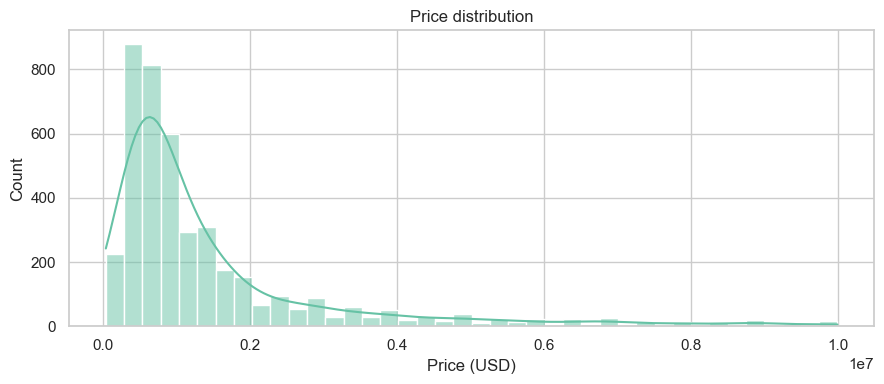

In [4]:
plt.figure(figsize=(9, 4))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Price distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Các biến mới được tạo từ thông tin có sẵn trước khi dự đoán giá. Notebook này **không dùng biến có chứa target leakage** như `price_per_sqft` làm input, vì biến đó phụ thuộc trực tiếp vào `price`.

In [4]:
def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    rooms = (X["bed"] + X["bath"]).replace(0, np.nan)

    X["rooms_total"] = X["bed"] + X["bath"]
    X["living_per_room"] = X["living"] / rooms
    X["log_living"] = np.log1p(X["living"].clip(lower=0))
    X["log_lot_sqft"] = np.log1p(X["lot_sqft"].clip(lower=0))
    X["is_near_coast"] = (X["dist_coast"] < 10).astype(int)
    X["is_near_city"] = (X["dist_city"] < 10).astype(int)
    X["income_x_bachelor"] = X["income"] * X["bachelor"]
    X["risk_exposure"] = X[["risk_fire", "risk_earthquake", "risk_heat"]].mean(axis=1)

    X = X.replace([np.inf, -np.inf], np.nan)
    return X.fillna(X.median(numeric_only=True))

X_base = df.drop(columns=["price"])
y = df["price"]
X = add_engineered_features(X_base)

engineered_columns = sorted(set(X.columns) - set(X_base.columns))
print(f"Original features: {X_base.shape[1]}")
print(f"Features after engineering: {X.shape[1]}")
engineered_columns

Original features: 31
Features after engineering: 39


['income_x_bachelor',
 'is_near_city',
 'is_near_coast',
 'living_per_room',
 'log_living',
 'log_lot_sqft',
 'risk_exposure',
 'rooms_total']

## 4. Train/Test Split & hàm đánh giá

Test set được giữ riêng để đánh giá cuối cùng. Cross-validation chỉ thực hiện trên training set để giảm rủi ro overfitting vào test set.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

def evaluate_regression(model, X_eval, y_eval) -> dict:
    pred = model.predict(X_eval)
    return {
        "MAE": mean_absolute_error(y_eval, pred),
        "Median AE": median_absolute_error(y_eval, pred),
        "RMSE": root_mean_squared_error(y_eval, pred),
        "R2": r2_score(y_eval, pred),
        "MAPE (%)": mean_absolute_percentage_error(y_eval, pred) * 100,
    }

def format_metric_table(df_metrics: pd.DataFrame) -> pd.DataFrame:
    formatted = df_metrics.copy()
    for col in ["MAE", "Median AE", "RMSE"]:
        formatted[col] = formatted[col].round(0).astype(int)
    formatted["R2"] = formatted["R2"].round(3)
    formatted["MAPE (%)"] = formatted["MAPE (%)"].round(2)
    return formatted

Train shape: (3400, 39)
Test shape: (851, 39)


## 5. Baseline models + 5-fold Cross-validation

In [8]:
models = {
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=20000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        random_state=RANDOM_STATE,
        n_jobs=1,
        min_samples_leaf=1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_fold_mae = {}
cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    mae_scores = -scores["test_mae"]
    rmse_scores = -scores["test_rmse"]
    r2_scores = scores["test_r2"]
    cv_fold_mae[name] = mae_scores

    cv_rows.append({
        "Model": name,
        "CV MAE mean": mae_scores.mean(),
        "CV MAE std": mae_scores.std(),
        "CV RMSE mean": rmse_scores.mean(),
        "CV R2 mean": r2_scores.mean(),
    })

cv_summary = pd.DataFrame(cv_rows).sort_values("CV MAE mean")
cv_summary_display = cv_summary.copy()
for col in ["CV MAE mean", "CV MAE std", "CV RMSE mean"]:
    cv_summary_display[col] = cv_summary_display[col].round(0).astype(int)
cv_summary_display["CV R2 mean"] = cv_summary_display["CV R2 mean"].round(3)
cv_summary_display

,Model,CV MAE mean,CV MAE std,CV RMSE mean,CV R2 mean
2,XGBoost,361462,23479,729496,0.820
1,Random Forest,362840,25148,740208,0.814
0,ElasticNet,597039,17506,967256,0.680


## 6. Hyperparameter Tuning

Tuning được thực hiện bằng `RandomizedSearchCV` trên training set. Sau khi tìm bộ tham số tốt, mô hình được đánh giá lại bằng 5-fold CV và test set.

In [9]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions={
        "n_estimators": [200, 300, 400],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7, 1.0],
    },
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_distributions={
        "n_estimators": [300, 500, 700],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.03, 0.05, 0.08],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_lambda": [1, 5, 10],
    },
    n_iter=12,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

tuning_summary = pd.DataFrame([
    {
        "Model": "Random Forest Tuned",
        "Best CV MAE": -rf_search.best_score_,
        "Best Params": rf_search.best_params_,
    },
    {
        "Model": "XGBoost Tuned",
        "Best CV MAE": -xgb_search.best_score_,
        "Best Params": xgb_search.best_params_,
    },
])

tuning_summary_display = tuning_summary.copy()
tuning_summary_display["Best CV MAE"] = tuning_summary_display["Best CV MAE"].round(0).astype(int)
tuning_summary_display

,Model,Best CV MAE,Best Params
0,Random Forest Tuned,370238,"{'n_estimators': 200, 'min_samples_split': 2, ..."
1,XGBoost Tuned,350818,"{'subsample': 0.75, 'reg_lambda': 1, 'n_estima..."


In [9]:
tuned_models = {
    "Random Forest Tuned": rf_search.best_estimator_,
    "XGBoost Tuned": xgb_search.best_estimator_,
}

tuned_cv_rows = []
for name, model in tuned_models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    mae_scores = -scores["test_mae"]
    rmse_scores = -scores["test_rmse"]
    r2_scores = scores["test_r2"]
    cv_fold_mae[name] = mae_scores

    tuned_cv_rows.append({
        "Model": name,
        "CV MAE mean": mae_scores.mean(),
        "CV MAE std": mae_scores.std(),
        "CV RMSE mean": rmse_scores.mean(),
        "CV R2 mean": r2_scores.mean(),
    })

cv_all = pd.concat([cv_summary, pd.DataFrame(tuned_cv_rows)], ignore_index=True).sort_values("CV MAE mean")
cv_all_display = cv_all.copy()
for col in ["CV MAE mean", "CV MAE std", "CV RMSE mean"]:
    cv_all_display[col] = cv_all_display[col].round(0).astype(int)
cv_all_display["CV R2 mean"] = cv_all_display["CV R2 mean"].round(3)
cv_all_display

,Model,CV MAE mean,CV MAE std,CV RMSE mean,CV R2 mean
4,XGBoost Tuned,341311,22336,701963,0.833
0,XGBoost,361462,23479,729496,0.820
3,Random Forest Tuned,361914,24522,737475,0.816
1,Random Forest,362840,25148,740208,0.814
2,ElasticNet,597039,17506,967256,0.680


## 7. Đánh giá cuối trên Test set

In [10]:
all_models = {**models, **tuned_models}

test_rows = []
for name, model in all_models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_regression(model, X_test, y_test)
    metrics["Model"] = name
    test_rows.append(metrics)

test_results = pd.DataFrame(test_rows).set_index("Model").sort_values("MAE")
test_results_display = format_metric_table(test_results)
test_results_display

,MAE,Median AE,RMSE,R2,MAPE (%)
Model,,,,,
XGBoost Tuned,345285,126859,682954,0.830,23.20
Random Forest,358699,130588,732212,0.804,24.18
Random Forest Tuned,361441,134201,734174,0.803,24.79
XGBoost,366634,147656,707909,0.817,25.49
ElasticNet,571111,368053,934695,0.681,61.40


In [11]:
best_model_name = test_results.index[0]
best_model = all_models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"Best model by test MAE: {best_model_name}")
display(test_results_display.loc[[best_model_name]])

Best model by test MAE: XGBoost Tuned


,MAE,Median AE,RMSE,R2,MAPE (%)
Model,,,,,
XGBoost Tuned,345285,126859,682954,0.83,23.2


## 8. Kiểm định thống kê đơn giản trên CV folds

Vì số fold chỉ là 5, kiểm định này nên được xem là bằng chứng hỗ trợ chứ không phải kết luận tuyệt đối. Tuy nhiên, nó giúp báo cáo không chỉ dựa vào một lần train/test split.

In [12]:
stat_tests = []
for baseline_name, tuned_name in [
    ("Random Forest", "Random Forest Tuned"),
    ("XGBoost", "XGBoost Tuned"),
]:
    baseline_mae = cv_fold_mae[baseline_name]
    tuned_mae = cv_fold_mae[tuned_name]
    statistic, p_value = ttest_rel(baseline_mae, tuned_mae)
    stat_tests.append({
        "Comparison": f"{baseline_name} vs {tuned_name}",
        "Baseline CV MAE": baseline_mae.mean(),
        "Tuned CV MAE": tuned_mae.mean(),
        "Mean MAE improvement": baseline_mae.mean() - tuned_mae.mean(),
        "paired t-test p-value": p_value,
    })

stat_tests_df = pd.DataFrame(stat_tests)
stat_tests_display = stat_tests_df.copy()
for col in ["Baseline CV MAE", "Tuned CV MAE", "Mean MAE improvement"]:
    stat_tests_display[col] = stat_tests_display[col].round(0).astype(int)
stat_tests_display["paired t-test p-value"] = stat_tests_display["paired t-test p-value"].round(4)
stat_tests_display

,Comparison,Baseline CV MAE,Tuned CV MAE,Mean MAE improvement,paired t-test p-value
0,Random Forest vs Random Forest Tuned,362840,361914,926,0.2298
1,XGBoost vs XGBoost Tuned,361462,341311,20151,0.0061


## 9. Feature Importance

Sử dụng permutation importance trên test set để đo mức tăng lỗi khi từng biến bị xáo trộn. Cách này dễ diễn giải hơn so với chỉ đọc importance nội bộ của tree model.

In [13]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mae_increase": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mae_increase", ascending=False)

importance_df.head(15)

,feature,importance_mae_increase,importance_std
2,living,358364.168246,16947.113082
30,dist_coast,133561.188789,7140.568808
11,lat,104715.518553,7644.065481
37,income_x_bachelor,71075.612013,5309.294753
1,bath,62855.149873,5404.670207
12,long,58033.712978,3863.491050
29,dist_airport,49873.242714,3439.005158
9,type_single,48731.834731,4731.714981
27,risk_heat,46575.197773,3090.105256
17,bachelor,35755.624793,4604.929544


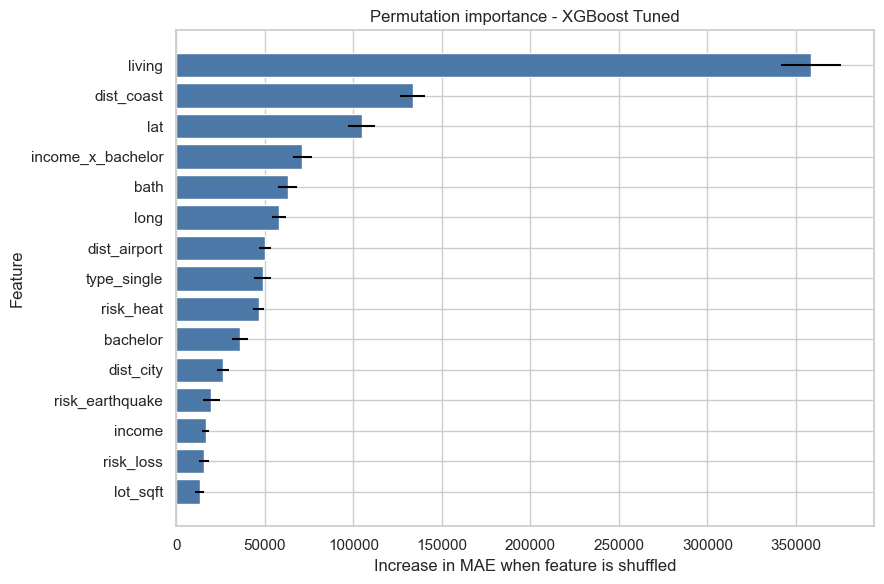

In [14]:
top_importance = importance_df.head(15).sort_values("importance_mae_increase")

plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature"], top_importance["importance_mae_increase"], xerr=top_importance["importance_std"], color="#4c78a8")
plt.title(f"Permutation importance - {best_model_name}")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Error Analysis

Phần này xem mô hình sai nhiều ở nhóm nhà nào, thay vì chỉ báo một con số MAE tổng.

In [15]:
def infer_home_type(row: pd.Series) -> str:
    type_cols = ["type_condo", "type_manufactured", "type_multi", "type_single", "type_townhouse"]
    active = [col.replace("type_", "") for col in type_cols if bool(row.get(col, False))]
    return active[0] if active else "unknown"

error_df = X_test.copy()
error_df["actual_price"] = y_test.values
error_df["predicted_price"] = y_pred
error_df["residual"] = error_df["actual_price"] - error_df["predicted_price"]
error_df["absolute_error"] = error_df["residual"].abs()
error_df["absolute_percentage_error"] = error_df["absolute_error"] / error_df["actual_price"].replace(0, np.nan) * 100
error_df["home_type"] = error_df.apply(infer_home_type, axis=1)
error_df["price_segment"] = pd.cut(
    error_df["actual_price"],
    bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
    labels=["<500k", "500k-1M", "1M-2M", ">2M"],
    include_lowest=True,
)

error_summary = pd.DataFrame([evaluate_regression(best_model, X_test, y_test)], index=[best_model_name])
format_metric_table(error_summary)

,MAE,Median AE,RMSE,R2,MAPE (%)
XGBoost Tuned,345285,126859,682954,0.83,23.2


In [16]:
segment_error = (
    error_df
    .groupby("price_segment", observed=True)
    .agg(
        count=("actual_price", "size"),
        avg_actual_price=("actual_price", "mean"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        mape=("absolute_percentage_error", "mean"),
    )
    .reset_index()
)

segment_error_display = segment_error.copy()
for col in ["avg_actual_price", "mae", "median_ae"]:
    segment_error_display[col] = segment_error_display[col].round(0).astype(int)
segment_error_display["mape"] = segment_error_display["mape"].round(2)
segment_error_display

,price_segment,count,avg_actual_price,mae,median_ae,mape
0,<500k,198,356695,73851,39444,26.22
1,500k-1M,287,737751,148754,95340,20.08
2,1M-2M,209,1456661,352380,238113,24.08
3,>2M,157,4226178,1037418,699846,23.95


In [17]:
type_error = (
    error_df
    .groupby("home_type")
    .agg(
        count=("actual_price", "size"),
        avg_actual_price=("actual_price", "mean"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        mape=("absolute_percentage_error", "mean"),
    )
    .sort_values("mae", ascending=False)
    .reset_index()
)

type_error_display = type_error.copy()
for col in ["avg_actual_price", "mae", "median_ae"]:
    type_error_display[col] = type_error_display[col].round(0).astype(int)
type_error_display["mape"] = type_error_display["mape"].round(2)
type_error_display

,home_type,count,avg_actual_price,mae,median_ae,mape
0,multi,37,1499321,507317,315727,38.54
1,condo,131,1105037,369640,101028,26.73
2,single,614,1612938,341058,128953,20.55
3,townhouse,44,1156864,307170,132612,22.93
4,manufactured,25,353262,148738,66979,47.66


In [18]:
worst_predictions = (
    error_df[["actual_price", "predicted_price", "absolute_error", "absolute_percentage_error", "home_type", "living", "bed", "bath", "dist_coast", "income", "bachelor"]]
    .sort_values("absolute_error", ascending=False)
    .head(10)
    .copy()
)

for col in ["actual_price", "predicted_price", "absolute_error", "living", "income"]:
    worst_predictions[col] = worst_predictions[col].round(0).astype(int)
worst_predictions["absolute_percentage_error"] = worst_predictions["absolute_percentage_error"].round(2)
worst_predictions["dist_coast"] = worst_predictions["dist_coast"].round(2)
worst_predictions["bachelor"] = worst_predictions["bachelor"].round(3)
worst_predictions

,actual_price,predicted_price,absolute_error,absolute_percentage_error,home_type,living,bed,bath,dist_coast,income,bachelor
1545,8195000,3515805,4679195,57.10,single,2867,4.0,4.0,16.31,117411,0.734
1738,7295000,2754440,4540560,62.24,condo,2041,3.0,2.0,17.07,111836,0.608
318,8900000,4823310,4076690,45.81,single,6027,5.0,6.0,22.15,107787,0.496
3637,9995000,5950474,4044526,40.47,single,3433,3.0,4.0,30.65,198594,0.743
3762,9995000,6333744,3661256,36.63,condo,4341,3.0,4.0,1.76,229363,0.743
3629,6900000,3466936,3433064,49.75,single,1619,3.0,2.0,16.78,182159,0.708
4008,5950000,2543390,3406610,57.25,condo,1392,2.0,3.0,5.38,163490,0.659
3988,9450000,6085600,3364400,35.60,single,4481,4.0,5.0,5.59,141453,0.655
3159,8900000,5538595,3361405,37.77,single,3310,4.0,5.0,104.98,130703,0.586
2634,6750000,3709447,3040553,45.05,single,7762,7.0,9.0,113.13,56250,0.390


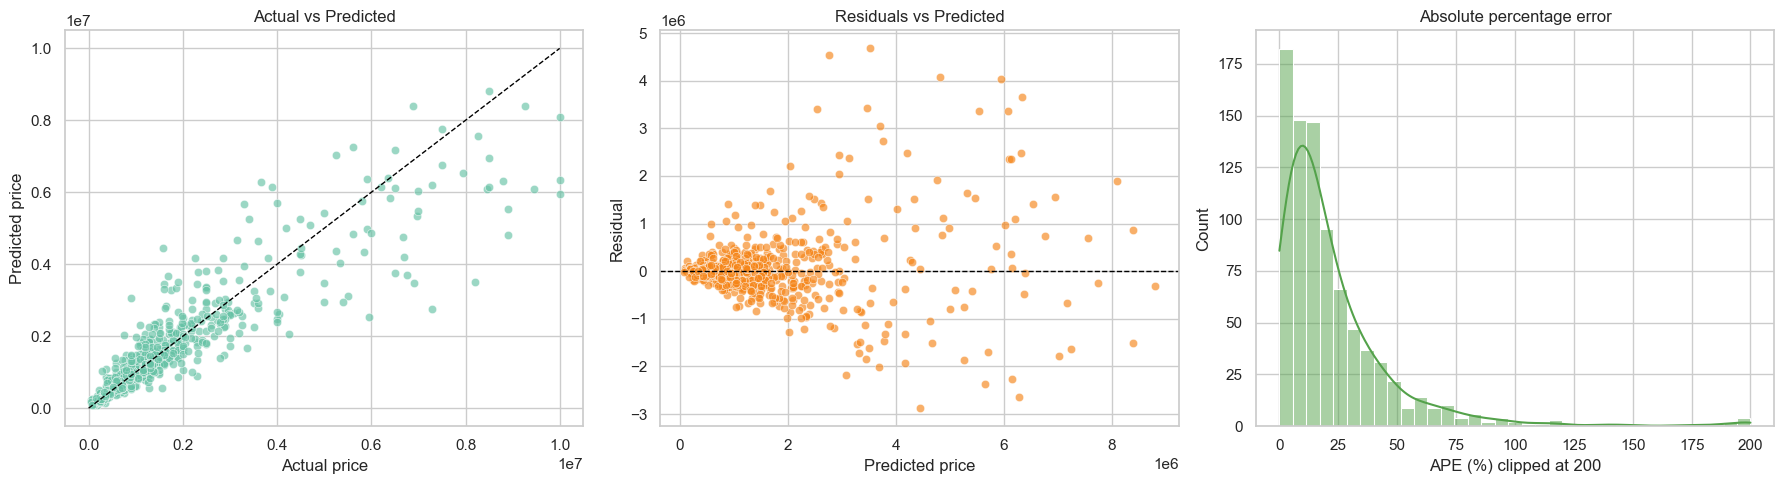

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=error_df["actual_price"], y=error_df["predicted_price"], ax=axes[0], alpha=0.65)
limit = max(error_df["actual_price"].max(), error_df["predicted_price"].max())
axes[0].plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1)
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

sns.scatterplot(x=error_df["predicted_price"], y=error_df["residual"], ax=axes[1], alpha=0.65, color="#f58518")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Residual")

sns.histplot(error_df["absolute_percentage_error"].clip(upper=200), bins=35, kde=True, ax=axes[2], color="#54a24b")
axes[2].set_title("Absolute percentage error")
axes[2].set_xlabel("APE (%) clipped at 200")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 11. Kết luận chính

- Feature Engineering bổ sung thông tin phi tuyến như log diện tích, số phòng tổng, khoảng cách gần biển/gần thành phố và tương tác thu nhập - học vấn.
- 5-fold CV giúp đánh giá ổn định hơn so với chỉ một train/test split.
- XGBoost sau tuning là mô hình tốt nhất theo MAE trên test set.
- Kiểm định paired t-test trên CV folds cho thấy tuning XGBoost cải thiện MAE so với baseline với p-value nhỏ hơn 0.05 trong lần chạy này.
- Error Analysis cho thấy mô hình thường khó dự đoán hơn ở nhóm nhà giá cao, do giá trị tuyệt đối lớn và khả năng có yếu tố vị trí/độ sang trọng chưa được capture đầy đủ trong dataset.